In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [7]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [8]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
sc = StandardScaler()

target_column_nugget = "NuggetDiameter (mm)" 
target_column_class = "Category" 


x_train, y_train = get_features_and_target(train_df, target_column_nugget)
x_dev, y_dev = get_features_and_target(dev_df, target_column_nugget)

x_train_scale = sc.fit_transform(X=x_train)
x_dev_scale = sc.transform(x_dev)


# Define Nugget Model

In [24]:
#model = 'TabPFNNugget'
model = 'RandomForestNugget'
#model = 'XGBoostNugget'

# Fit Nugget Estimator


In [25]:
if model == 'TabPFNNugget':

    # Initialize the regressor
    regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
    # To use TabPFN v2:
    # regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)
    regressor.fit(x_train_scale, y_train)

    # Predict on the test set
    predictions = regressor.predict(x_dev_scale)

    # Predict on the test set
    predictions_nugget_train = regressor.predict(x_train)
    predictions_nugget_dev= regressor.predict(x_dev)

elif model == 'XGBoostNugget':

    # Convert the data into DMatrix format
    dtrain = xgb.DMatrix(x_train_scale, label=y_train)
    dtest = xgb.DMatrix(x_dev_scale, label=y_dev)

    # Set the parameters for the XGBoost model
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 3,
        'eta': 0.2,
        'eval_metric': 'rmse',
    }

    # Train the model
    num_boost_round = 10
    bst = xgb.train(params, dtrain, num_boost_round)

    # Make predictions
    predictions_nugget_train = bst.predict(dtrain)
    predictions_nugget_dev = bst.predict(dtest)

elif model == 'RandomForestNugget':

    # Set the parameters for the Random Forest model
    params = {
            'n_estimators': 98,
            'max_depth': 4,
            'min_samples_split': 3,
            'min_samples_leaf': 4,
            'random_state': 42,
    }

    predictions_nugget_train = RandomForestRegressor(**params).fit(x_train_scale, y_train).predict(x_train_scale)
    predictions_nugget_dev = RandomForestRegressor(**params).fit(x_train_scale, y_train).predict(x_dev_scale)






In [26]:
mae_nugget_train = mean_absolute_error(y_train, predictions_nugget_train)
rmse_nugget_train = np.sqrt(mean_squared_error(y_train, predictions_nugget_train))
print(f"MAE Nugget Diameter (mm) - Train: {mae_nugget_train}")
print(f"RMSE Nugget Diameter (mm) - Train: {rmse_nugget_train}")    
print(f"percentage error: {mae_nugget_train / np.mean(y_train) * 100:.2f}%")
print(f"percentage error: {rmse_nugget_train / np.mean(y_train) * 100:.2f}%")

MAE Nugget Diameter (mm) - Train: 0.1879748128351235
RMSE Nugget Diameter (mm) - Train: 0.25912757249525187
percentage error: 5.35%
percentage error: 7.37%


In [ ]:
predictions_nugget_train

array([2.6413379, 3.973597 , 2.683507 , 2.7150526, 4.091856 , 2.6489258,
       3.595269 , 2.682352 , 4.0461564, 2.6793032, 2.7906604, 2.6610904,
       2.6956367, 3.916206 , 3.7111793, 3.7187643, 2.6973155, 4.0762544,
       4.069511 , 4.0735564, 4.0395947, 4.060915 , 4.0760984, 4.0737286,
       4.0789022, 4.0552382, 4.0730796, 4.0646143, 4.0499167, 4.0649114,
       4.0752544, 3.9379754, 3.936605 , 3.7127695, 3.7478573, 3.7524114,
       3.6733074, 3.5081768, 3.4705586, 3.4821124, 3.4818332, 3.4601855,
       3.444871 , 3.449802 , 3.4410396, 3.444778 , 3.4756787, 3.3510962,
       3.3490453, 3.348771 , 3.3370254, 3.3465724, 3.341061 , 3.3421896,
       3.332669 , 3.334197 , 3.3420901, 3.335082 , 3.3264055, 3.3295908,
       3.3300457, 3.3315082, 3.3343792, 3.3365126, 3.3333259, 3.331419 ,
       3.3303308, 3.3314352, 3.332279 , 3.3330493, 3.333987 , 3.3321068,
       3.3405106, 3.3435879, 3.3539567, 3.3526764, 3.342393 , 3.3484516,
       3.3502808, 3.3470917, 3.3453908, 3.3438535, 

# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [12]:
def compute_interfacial_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     f_pull = 1 * (np.pi/4) * (nugget_prediction)**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1).iloc[0]
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((nugget_prediction) + 2*t)*t*365 
     return np.round(f_pull, 1) 

# Fit Model

In [ ]:
# Target value

x_train, y_train = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [13]:
def compute_pullforces(x, y, predictions_class, predictions_nugget):
    pullforces = []

    for sample_id, pred, nugget_value in zip(y.index, predictions_class, predictions_nugget):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df, nugget_value)
        else:
            value = compute_pullout_failure(row_x_df, nugget_value)

        pullforces.append(value)

    return np.array(pullforces)


In [14]:
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train, predictions_nugget_train)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev, predictions_nugget_dev)


KeyError: "None of [Index([0], dtype='int64', name='Sample ID')] are in the [index]"

In [ ]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()

In [ ]:
print(pullforces_dev)

[5725.8        1400.5        5782.4        1402.69995117 6151.4
 1435.59997559 6149.9        1478.09997559 4046.4        3826.5
 3897.         3497.5        3557.9        3492.4        3401.2
 3429.2        3357.2        3404.6        3240.2        3425.6
 3354.5        3377.5        3289.5        3307.5        3330.
 3349.7        3281.5        3316.3        3272.8        3310.1
 3258.3        3274.1        3365.4        3365.2        3262.1
 3392.6        3406.4        3302.3        3333.         3367.4
 3304.5        3400.5        3381.8        3495.         3551.7
 3554.6        3586.6        3588.2        3497.4        3434.8
 3419.4        3403.5        3520.6        3505.4        3526.7
 3515.7        3535.7        3480.5        3513.1        3531.7
 3516.4        3465.2        3486.2        3387.7        3366.1
 3364.5        3330.2        3300.3        3318.9        3364.8
 3336.3        3442.8        3395.6        3397.1        3348.5
 3341.6        3379.         3330.5      

# Fit 2nd Model

In [ ]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_Regressor)

# Predict on the test set
final_pred = regressor.predict(x_dev)

In [ ]:
final_pred

array([4170.6094, 2147.6226, 4183.539 , 2147.9988, 5198.001 , 2247.6548,
       5150.5415, 2275.8022, 3338.912 , 3307.4614, 3323.2046, 2859.8506,
       2870.7544, 2861.5166, 2841.5583, 2845.353 , 2829.0354, 2845.9753,
       2734.582 , 2760.0825, 2740.755 , 2743.9438, 2734.1462, 2725.208 ,
       2732.8545, 2764.5293, 2738.727 , 2746.4873, 2744.2283, 2740.6206,
       2738.6406, 2737.606 , 2739.375 , 2741.2002, 2768.7627, 2777.7214,
       2777.1245, 2767.724 , 2754.9048, 2771.8396, 2769.1262, 2775.0776,
       2775.2925, 3106.0723, 3115.3354, 3118.0317, 3122.2124, 3121.454 ,
       3087.2866, 3074.1309, 3091.1072, 3087.0454, 3107.6287, 3053.227 ,
       3066.58  , 3060.1958, 3060.9238, 3045.0068, 3052.2034, 3054.1025,
       3059.5847, 3049.7832, 3050.669 , 2977.2   , 2974.2048, 2963.7983,
       2962.974 , 2948.1086, 2949.9773, 2961.6904, 2962.813 , 2973.7085,
       2964.2883, 2971.4338, 2965.742 , 2959.189 , 2956.5144, 2914.494 ,
       2922.9126, 2929.539 , 2926.0063, 2915.6565, 

In [ ]:
y_dev

0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

# Check Validation Data

In [ ]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [ ]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")


MAE:  126.26
RMSE: 219.93
R2: 0.62


# Model

In [46]:
#model_name_nugget = 'TabPFNNugget'
model_name_nugget = 'RandomForestNugget'
#model_name_nugget = 'XGBoostNugget'

#model_name_class = 'TabPFNClassifier'
model_name_class = 'RandomForestClassifier'
#model_name_class = 'XGBoostNuggetClassifier'

#model_name_reg = 'TabPFN'
model_name_reg = 'RandomForest'
#model_name_reg = 'XGBoost'

# Cross Validation


Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
192        235              60                400            0      92.76   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
192       3707.1             0.628             0.634  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
192        2616.7                 3.07      Bad      NaN  


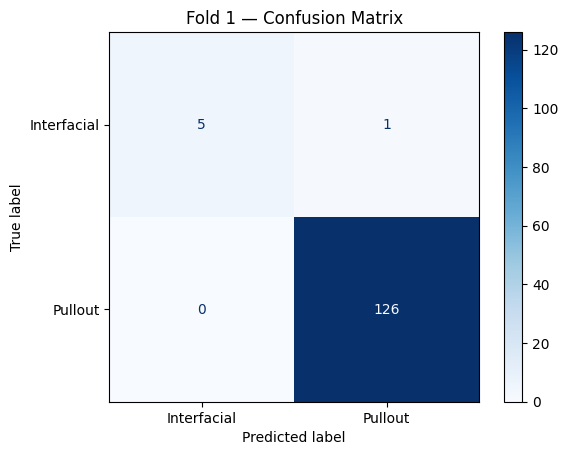

F1 Score: 0.9525691699604744



=== Fold 1 ===
Direct:
 MAE=147.24,
 RMSE=211.06,
 R²=0.69

Hybrid:
 MAE=140.87,
 RMSE=249.29,
 R²=0.57

Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
384        480              60               1200            0      98.49   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
384      2308.35             0.624             0.626  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
384        1410.3                  1.9      Bad      NaN  


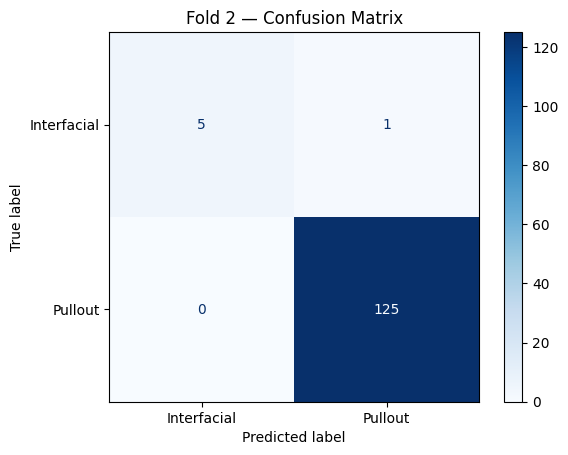

F1 Score: 0.9525534226729446



=== Fold 2 ===
Direct:
 MAE=143.00,
 RMSE=255.75,
 R²=0.70

Hybrid:
 MAE=135.28,
 RMSE=266.60,
 R²=0.67

Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
154        189              60                400            0      91.17   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
154       3119.0              0.64             0.633  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
154        2634.6                  2.7      Bad      NaN  


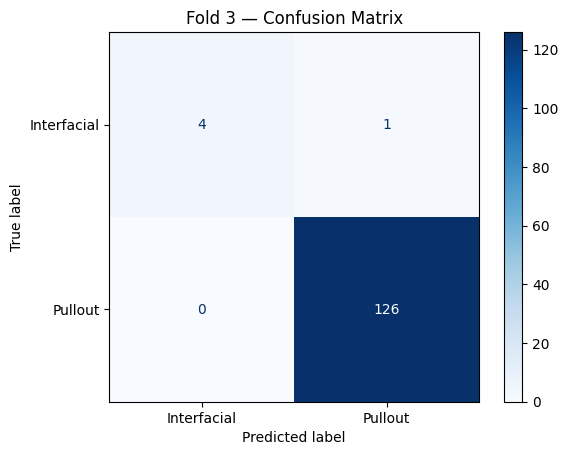

F1 Score: 0.9424681598594642



=== Fold 3 ===
Direct:
 MAE=139.95,
 RMSE=222.87,
 R²=0.66

Hybrid:
 MAE=131.65,
 RMSE=208.87,
 R²=0.70

=== FINAL CROSS‑VALIDATION RESULTS ===

--- Direct Model ---
mean MAE:  143.40 ± 2.99
mean RMSE: 229.89 ± 18.91
mean R²:   0.68 ± 0.02

--- Hybrid Model ---
mean MAE:  135.93 ± 3.79
mean RMSE: 241.59 ± 24.19
mean R²:   0.65 ± 0.06
mean RMSE: 0.308308 ± 0.003473


In [47]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mapping = {
    "Explode": "Pullout",
    "Good": "Pullout",
    "Bad": "Interfacial"
}

def apply_mapping(arr):
    return np.array([mapping[x] for x in arr])

#Metrics with and without physical inference
direct_mae, direct_rmse, direct_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 
nugget_mae, nugget_rmse = [], []

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):

    # Build fold-specific data
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    train_df["Category"] = apply_mapping(train_df["Category"])
    val_df["Category"] = apply_mapping(val_df["Category"])

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    # Extract features for nugget, class, regression
    x_tr_nug, y_tr_nug = get_features_and_target(x_train, target_column_nugget)
    x_val_nug, y_val_nug = get_features_and_target(x_val, target_column_nugget)

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    # Nugget estimation
    if model_name_nugget == 'TabPFNNugget':
        regressor_nug = TabPFNRegressor()
        regressor_nug.fit(x_tr_nug, y_tr_nug)

        # Predict on sample-level train and val
        predictions_nugget_train = pd.Series(
            regressor_nug.predict(x_tr_nug),
            index=x_tr_nug.index
        )
        predictions_nugget_dev = pd.Series(
            regressor_nug.predict(x_val_nug),
            index=x_val_nug.index
        )

    elif model_name_nugget == 'XGBoostNugget':
        # If you want to use XGBoost, use the sample-level x_tr_nug / x_val_nug
        dtrain = xgb.DMatrix(x_tr_nug, label=y_tr_nug)
        dtest = xgb.DMatrix(x_val_nug, label=y_val_nug)

        params = {
            'objective': 'reg:squarederror',
            'max_depth': 3,
            'eta': 0.2,
            'eval_metric': 'rmse',
        }
        num_boost_round = 10
        bst = xgb.train(params, dtrain, num_boost_round)

        predictions_nugget_train = pd.Series(bst.predict(dtrain), index=x_tr_nug.index)
        predictions_nugget_dev   = pd.Series(bst.predict(dtest),  index=x_val_nug.index)

    elif model_name_nugget == 'RandomForestNugget':
        params = {
            'n_estimators': 98,
            'max_depth': 4,
            'min_samples_split': 3,
            'min_samples_leaf': 4,
            'random_state': 42,
        }
        rf_nug = RandomForestRegressor(**params)
        rf_nug.fit(x_tr_nug, y_tr_nug)

        predictions_nugget_train = pd.Series(rf_nug.predict(x_tr_nug), index=x_tr_nug.index)
        predictions_nugget_dev   = pd.Series(rf_nug.predict(x_val_nug), index=x_val_nug.index)

    nugget_mae.append(mean_absolute_error(y_val_nug, predictions_nugget_dev)) 
    nugget_rmse.append(np.sqrt(mean_squared_error(y_val_nug, predictions_nugget_dev))) 



    # -----------------------------
    # XGBoost CLASSIFIER
    # -----------------------------
    if model_name_class == 'XGBoostClassifier':

        params = {
            "max_depth": 5,
            "learning_rate": 0.3,
            "n_estimators": 177,
            "tree_method": "hist",
            "eval_metric": "mlogloss"
        }

        # Encode labels → integers (required for XGBClassifier)
        le = LabelEncoder()
        y_val_class = le.fit_transform(y_val_class)
        y_tr_class = le.transform(y_tr_class)

        classifier = XGBClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)
        # Reverse LabelEncoder back to original class names
        preds = le.inverse_transform(preds)
        y_val_class = le.inverse_transform(y_val_class)


    # -----------------------------
    # RANDOM FOREST CLASSIFIER
    # -----------------------------
    elif model_name_class == 'RandomForestClassifier':

        
        params = {
            'n_estimators': 27,
            'max_depth': 7,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'max_features': 'log2',
        }

        classifier = RandomForestClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

    # -----------------------------
    # TABPFN CLASSIFIER
    # -----------------------------
    elif model_name_class == 'TabPFNClassifier':

        classifier = TabPFNClassifier()
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

    mis_idx = np.where(preds != y_val_class)[0]

    if len(mis_idx) > 0:
        mis_sample_ids = x_val_class.index[mis_idx]   # correct index space
        print("\nMisclassified rows:")
        print(cross_df[cross_df["Sample ID"].isin(mis_sample_ids)])


    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=preds,
        class_labels=["Interfacial", "Pullout"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )

    
    if model_name_reg == 'TabPFN':

        # Initialize the regressor
        regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
        # To use TabPFN v2:
        # regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)
        regressor.fit(x_tr_reg, y_tr_reg)

        # Predict on the test set
        predictions_regression_dev_without_physics = regressor.predict(x_val_reg)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)




    elif model_name_reg == 'XGBoost':

        # Convert the data into DMatrix format
        dtrain = xgb.DMatrix(x_tr_reg, label=y_train)
        dtest = xgb.DMatrix(x_val_reg, label=y_val_reg)

        # Set the parameters for the XGBoost model
        params = {
            'objective': 'reg:squarederror',
            'max_depth': 1,
            'eta': 0.57,
            'eval_metric': 'rmse',
        }

        # Train the model
        num_boost_round = 13
        bst = xgb.train(params, dtrain, num_boost_round)

        # Make predictions
        predictions_regression_dev_without_physics = bst.predict(dtest)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)


    elif model_name_reg == 'RandomForest':

        # Set the parameters for the Random Forest model
        params = {
                'n_estimators': 19,
                'max_depth': 5,
                'min_samples_split': 6,
                'min_samples_leaf': 3,
                'random_state': 42,
        }

        predictions_regression_dev_without_physics = RandomForestRegressor(**params).fit(x_tr_reg, y_tr_reg).predict(x_val_reg)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)



    direct_mae.append(mean_absolute_error(y_val_reg, predictions_regression_dev_without_physics)) 
    direct_rmse.append(np.sqrt(mean_squared_error(y_val_reg, predictions_regression_dev_without_physics))) 
    direct_r2.append(r2_score(y_val_reg, predictions_regression_dev_without_physics))

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=predictions_regression_dev_without_physics,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction ({model_name_reg}) by Category"
    )

    x_tr_hybrid = x_tr_reg.copy() 
    x_val_hybrid = x_val_reg.copy() 

    physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train, predictions_nugget_train) 
    physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev, predictions_nugget_dev)

    x_tr_hybrid["Physical_Inference"] = physics_train 
    x_val_hybrid["Physical_Inference"] = physics_val 
    
    hybrid_model = TabPFNRegressor() 
    hybrid_model.fit(x_tr_hybrid, y_train_reg) 
    
    hybrid_pred = hybrid_model.predict(x_val_hybrid) 
    hybrid_mae.append(mean_absolute_error(y_val_reg, hybrid_pred)) 
    hybrid_rmse.append(np.sqrt(mean_squared_error(y_val_reg, hybrid_pred))) 
    hybrid_r2.append(r2_score(y_val_reg, hybrid_pred))  

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=hybrid_pred,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction ({model_name_reg}) by Category with Physical Inference"
    )

    print(f"\n=== Fold {fold+1} ===") 
    print(f"Direct:\n MAE={direct_mae[-1]:.2f},\n RMSE={direct_rmse[-1]:.2f},\n R²={direct_r2[-1]:.2f}\n")
    print(f"Hybrid:\n MAE={hybrid_mae[-1]:.2f},\n RMSE={hybrid_rmse[-1]:.2f},\n R²={hybrid_r2[-1]:.2f}")


print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Direct Model ---") 
print(f"mean MAE:  {np.mean(direct_mae):.2f} ± {np.std(direct_mae):.2f}")
print(f"mean RMSE: {np.mean(direct_rmse):.2f} ± {np.std(direct_rmse):.2f}")
print(f"mean R²:   {np.mean(direct_r2):.2f} ± {np.std(direct_r2):.2f}")

print("\n--- Hybrid Model ---") 
print(f"mean MAE:  {np.mean(hybrid_mae):.2f} ± {np.std(hybrid_mae):.2f}")
print(f"mean RMSE: {np.mean(hybrid_rmse):.2f} ± {np.std(hybrid_rmse):.2f}")
print(f"mean R²:   {np.mean(hybrid_r2):.2f} ± {np.std(hybrid_r2):.2f}")

print(f"mean RMSE: {np.mean(nugget_rmse):.6f} ± {np.std(nugget_rmse):.6f}")


# Hyperparametertuning Nugget Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model_name = "rf"  # or "xgbregressor"

def create_regressor(model_name, params):
    if model_name == "rf":
        return RandomForestRegressor(**params, random_state=42)
    elif model_name == "xgb":
        return XGBRegressor(
            **params,
            random_state=42,
            tree_method="hist",
            eval_metric="rmse"
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")



In [ ]:
from scipy.stats import randint, uniform

param_spaces = {
    "rf": {
        "n_estimators": randint(50, 300),
        "max_depth": randint(3, 20),
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 10)
    },
    "xgb": {
          # Erster Durchlauf: randint(50, 300)
        'max_depth' : randint(1, 5),
        'learning_rate': randint(10, 31),  #Erster durchlauf: randint(1, 11)
        'n_estimators' : randint(1, 50),  

    }
}

In [ ]:
def sample_params(space):
    params = {}
    for k, v in space.items():
        val = v.rvs()

        # Convert learning_rate integer → stepped float
        if k == "learning_rate":
            val = round(val / 100.0, 2)   # erster durchlauf: val = round(val / 10.0, 1) 1→0.1, 2→0.2, ..., 10→1.0

        params[k] = val
    return params


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

def randomized_cv_search(model_name, cross_df, target_column, n_iter):
    space = param_spaces[model_name]

    best_rmse = float("inf")
    best_params = None
    best_model = None

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for i in range(n_iter):
        params = sample_params(space)
        print(f"\nTesting params: {params}")

        mae_list, rmse_list, r2_list = [], [], []

        for fold, (train_index, val_index) in enumerate(
                skf.split(cross_df["Sample ID"], cross_df["Category"])):

            train_df = cross_df.iloc[train_index].copy()
            val_df   = cross_df.iloc[val_index].copy()

            X_tr, y_tr = get_features_and_target(train_df, target_column)
            X_val, y_val = get_features_and_target(val_df, target_column)

            X_tr_scale = sc.fit_transform(X_tr)
            X_val_scale = sc.transform(X_val)

            model = create_regressor(model_name, params)
            model.fit(X_tr_scale, y_tr)

            preds = model.predict(X_val_scale)

            mae = mean_absolute_error(y_val, preds)
            rmse = np.sqrt(np.mean((y_val - preds)**2))
            r2 = r2_score(y_val, preds)

            mae_list.append(mae)
            rmse_list.append(rmse)
            r2_list.append(r2)

        rmse_mean = np.mean(rmse_list)
        print(f"RMSE={rmse_mean:.3f}")

        if rmse_mean < best_rmse:
            best_rmse = rmse_mean
            best_params = params
            best_model = model

    return best_model, best_params, best_rmse


In [ ]:
best_model, best_params, best_rmse = randomized_cv_search(
    model_name=model_name,
    cross_df=cross_df,
    target_column="NuggetDiameter (mm)",
    n_iter=10000
)


Testing params: {'n_estimators': 205, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 1}
RMSE=0.319

Testing params: {'n_estimators': 109, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 8}
RMSE=0.314

Testing params: {'n_estimators': 223, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 3}
RMSE=0.314

Testing params: {'n_estimators': 228, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 3}
RMSE=0.315

Testing params: {'n_estimators': 222, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1}
RMSE=0.313

Testing params: {'n_estimators': 203, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 8}
RMSE=0.314

Testing params: {'n_estimators': 166, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 1}
RMSE=0.321

Testing params: {'n_estimators': 227, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 4}
RMSE=0.314

Testing params: {'n_estimators': 175, 'max_depth': 7, 'min_samples_split': 6, 'min_samples

In [ ]:
print("\n==============================")
print(" BEST MODEL FOUND ")
print("==============================")
print(f"Best RMSE:   {best_rmse:.2f}")
print(f"Best Params: {best_params}")


#==============================
# BEST MODEL FOUND XGBoost Nugget Estimation
#==============================
#Best RMSE:   0.31
#Best Params: {'max_depth': 3, 'learning_rate': 0.2, 'n_estimators': 10}

#==============================
# BEST MODEL FOUND 
#==============================
#Best RMSE:   0.3081794789457622
#Best Params: {'n_estimators': 98, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 4}


 BEST MODEL FOUND 
Best RMSE:   0.3081794789457622
Best Params: {'n_estimators': 98, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 4}
